In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import joblib

In [71]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [72]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [73]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value = 0)

In [74]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [75]:
y_train

,Churn
0,No
1,No
2,Yes
3,Yes
4,No
...,...
5629,Yes
5630,No
5631,No
5632,Yes


In [76]:
y_test

,Churn
0,Yes
1,No
2,No
3,Yes
4,No
...,...
1404,No
1405,No
1406,No
1407,No


In [77]:
model = LogisticRegression(max_iter=1000)

In [78]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,21,64.85,1336.800,True,False,True,False,False,True,...,True,False,True,False,True,False,False,False,False,True
1,0,54,97.20,5129.450,True,False,True,False,True,False,...,True,False,False,True,False,True,True,False,False,False
2,0,1,23.45,23.450,False,True,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
3,0,4,70.20,237.950,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False
4,0,0,61.90,1397.475,False,True,True,False,False,True,...,False,False,False,True,False,True,True,False,False,False


In [79]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [80]:
y_pred = model.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score

In [82]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8218594748048261


In [83]:
from sklearn.metrics import classification_report

In [84]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1036
         Yes       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [85]:
from sklearn.metrics import confusion_matrix

In [86]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[933 103]
 [148 225]]


In [87]:
import os
os.makedirs("results/result_graphs", exist_ok=True)

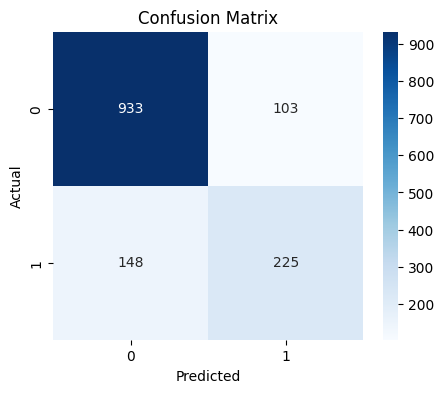

In [88]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/result_graphs/confusion_matrix.png")
plt.show()

In [89]:
os.makedirs("results/metrics", exist_ok = True)

In [96]:
report = classification_report(y_test, y_pred)

print("Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(report)

with open("results/metrics/model_metrics.txt", "w") as f:
    f.write(f"Accuracy: \n")
    f.write(str(accuracy))

    f.write("\n\n")
    f.write("Classification Report:\n")
    f.write(report)

Accuracy:
0.8218594748048261

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1036
         Yes       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [97]:
with open("results/metrics/model_metrics.txt", "r") as f:
  print(f.read())

Accuracy: 
0.8218594748048261

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1036
         Yes       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [91]:
import joblib

In [92]:
os.makedirs("models", exist_ok=True)

In [93]:
joblib.dump(model, "models/churn_model.pkl")

['models/churn_model.pkl']

In [94]:
print(os.listdir("models"))
print(os.listdir("results/metrics"))
print(os.listdir("results/result_graphs"))

['churn_model.pkl']
['model_metrics.txt']
['confusion_matrix.png']
